In [32]:
# ============================================================
# CELL 1: IMPORTS + PATHS
# ============================================================

import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("TESTING ENVIRONMENT")
print("=" * 70)

print("Device :", device)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = r"C:\Users\psytr\Desktop\Projects\scene_graph"

NOTEBOOK_DIR = os.path.join(
    PROJECT_ROOT,
    "notebook"
)

MODEL_DIR = os.path.join(
    NOTEBOOK_DIR,
    "models"
)

CACHE_DIR = os.path.join(
    MODEL_DIR,
    "preprocessed_cache"
)

TRAIN_CACHE_DIR = os.path.join(
    CACHE_DIR,
    "train"
)

VAL_CACHE_DIR = os.path.join(
    CACHE_DIR,
    "val"
)


# ------------------------------------------------------------
# Checkpoint
# ------------------------------------------------------------

CHECKPOINT_PATH = os.path.join(
    MODEL_DIR,
    "best_full_fusion_30epoch.pt"
)


print()
print("Project root :", PROJECT_ROOT)
print("Model path   :", CHECKPOINT_PATH)
print("Val cache    :", VAL_CACHE_DIR)

print()
print("Checkpoint exists :", os.path.exists(CHECKPOINT_PATH))
print("Val cache exists  :", os.path.exists(VAL_CACHE_DIR))

TESTING ENVIRONMENT
Device : cpu

Project root : C:\Users\psytr\Desktop\Projects\scene_graph
Model path   : C:\Users\psytr\Desktop\Projects\scene_graph\notebook\models\best_full_fusion_30epoch.pt
Val cache    : C:\Users\psytr\Desktop\Projects\scene_graph\notebook\models\preprocessed_cache\val

Checkpoint exists : True
Val cache exists  : True


In [33]:
# ============================================================
# CELL 2: CHECK MODEL FILES
# ============================================================

RELATIONSHIP_DIR = os.path.join(
    MODEL_DIR,
    "relationship"
)

print("=" * 70)
print("RELATIONSHIP MODEL FILES")
print("=" * 70)

if os.path.exists(RELATIONSHIP_DIR):

    for file in sorted(os.listdir(RELATIONSHIP_DIR)):
        print(file)

else:
    print("❌ Relationship directory not found:")
    print(RELATIONSHIP_DIR)

RELATIONSHIP MODEL FILES
__init__.py
__pycache__
dataset.py
encoder.py
geometry.py
model.py
predictor.py
trainer.py
transforms.py


In [34]:
# ============================================================
# CELL 3: INSPECT CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu"
)

print("=" * 70)
print("CHECKPOINT CONTENTS")
print("=" * 70)

print("Type:", type(checkpoint))

if isinstance(checkpoint, dict):

    print("\nKeys:")

    for key in checkpoint.keys():
        print("  -", key)

else:
    print("Checkpoint is not a dictionary.")

CHECKPOINT CONTENTS
Type: <class 'dict'>

Keys:
  - epoch
  - model_state_dict
  - optimizer_state_dict
  - val_macro_f1
  - val_accuracy
  - val_loss
  - val_top5_accuracy
  - history
  - config


In [35]:
# ============================================================
# CELL 4: INSPECT VALIDATION CACHE
# ============================================================

val_files = sorted([
    f
    for f in os.listdir(VAL_CACHE_DIR)
    if f.endswith(".pt")
])

print("=" * 70)
print("VALIDATION CACHE")
print("=" * 70)

print("Number of .pt files :", len(val_files))

for f in val_files:
    print(" ", f)
    

VALIDATION CACHE
Number of .pt files : 9
  val_0000.pt
  val_0001.pt
  val_0002.pt
  val_0003.pt
  val_0004.pt
  val_0005.pt
  val_0006.pt
  val_0007.pt
  val_0008.pt


In [36]:
# ============================================================
# CELL 5: INSPECT ONE VALIDATION SHARD
# ============================================================

sample_file = os.path.join(
    VAL_CACHE_DIR,
    val_files[0]
)

sample = torch.load(
    sample_file,
    map_location="cpu"
)

print("=" * 70)
print("VALIDATION SHARD CONTENT")
print("=" * 70)

print("File:", sample_file)
print("Type:", type(sample))

if isinstance(sample, dict):

    print("\nKeys:")

    for key, value in sample.items():

        if torch.is_tensor(value):

            print(
                f"  {key:25s} "
                f"shape={tuple(value.shape)} "
                f"dtype={value.dtype}"
            )

        else:

            print(
                f"  {key:25s} "
                f"type={type(value)}"
            )

else:

    print("Shard is not a dictionary.")

VALIDATION SHARD CONTENT
File: C:\Users\psytr\Desktop\Projects\scene_graph\notebook\models\preprocessed_cache\val\val_0000.pt
Type: <class 'dict'>

Keys:
  visual                    shape=(10000, 512) dtype=torch.float32
  subject_label             shape=(10000,) dtype=torch.int64
  object_label              shape=(10000,) dtype=torch.int64
  geometry                  shape=(10000, 8) dtype=torch.float32
  target                    shape=(10000,) dtype=torch.int64
  image_index               shape=(10000,) dtype=torch.int64


In [37]:
# CELL 6: IMPORT CACHED RELATIONSHIP MODEL

from models.relationship.model import CachedRelationshipModel

print("CachedRelationshipModel imported successfully")

CachedRelationshipModel imported successfully


In [38]:
# CELL 7: BUILD CACHED RELATIONSHIP MODEL

model = CachedRelationshipModel(
    num_object_classes=150,
    num_predicate_classes=51,
    visual_dim=512,
    label_embedding_dim=64,
    geometry_dim=32,
    hidden_dim=256,
    dropout=0.30,
)

model = model.to(device)

print("Model created successfully")
print()
print(model)

Model created successfully

CachedRelationshipModel(
  (subject_embedding): Embedding(150, 64)
  (object_embedding): Embedding(150, 64)
  (geometry_encoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=672, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=51, bias=True)
  )
)


In [39]:
# CELL 8: LOAD BEST FULL-FUSION CHECKPOINT

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Checkpoint loaded successfully")
print()
print("Checkpoint epoch    :", checkpoint["epoch"])
print("Validation Macro F1 :", checkpoint["val_macro_f1"])
print("Validation Accuracy :", checkpoint["val_accuracy"])
print("Validation Loss     :", checkpoint["val_loss"])
print("Validation Top-5    :", checkpoint["val_top5_accuracy"])

Checkpoint loaded successfully

Checkpoint epoch    : 7
Validation Macro F1 : 0.2759374397893987
Validation Accuracy : 0.6802198966438687
Validation Loss     : 1.4195962776173574
Validation Top-5    : 0.9573626528858492


In [40]:
# CELL 9: FIND VALIDATION SHARDS

val_files = sorted([
    f
    for f in os.listdir(VAL_CACHE_DIR)
    if f.startswith("val_") and f.endswith(".pt")
])

print("Validation shards found:")
for f in val_files:
    print(" ", f)

print()
print("Number of shards:", len(val_files))

Validation shards found:
  val_0000.pt
  val_0001.pt
  val_0002.pt
  val_0003.pt
  val_0004.pt
  val_0005.pt
  val_0006.pt
  val_0007.pt
  val_0008.pt

Number of shards: 9


In [41]:
# CELL 10: CACHED RELATIONSHIP DATASET

from torch.utils.data import Dataset, DataLoader


class CachedRelationshipDataset(Dataset):

    def __init__(self, cache):

        super().__init__()

        self.visual = cache["visual"]
        self.subject_label = cache["subject_label"]
        self.object_label = cache["object_label"]
        self.geometry = cache["geometry"]
        self.target = cache["target"]
        self.image_index = cache["image_index"]

        n = len(self.target)

        assert len(self.visual) == n
        assert len(self.subject_label) == n
        assert len(self.object_label) == n
        assert len(self.geometry) == n
        assert len(self.image_index) == n

    def __len__(self):
        return len(self.target)

    def __getitem__(self, index):

        return {
            "visual": self.visual[index],

            "subject_label":
                self.subject_label[index] - 1,

            "object_label":
                self.object_label[index] - 1,

            "geometry":
                self.geometry[index],

            "target":
                self.target[index],

            "image_index":
                self.image_index[index],
        }


print("CachedRelationshipDataset ready")

CachedRelationshipDataset ready


In [42]:
# CELL 11: LOAD ONE VALIDATION SHARD

first_val_path = os.path.join(
    VAL_CACHE_DIR,
    val_files[0]
)

cache = torch.load(
    first_val_path,
    map_location="cpu"
)

dataset = CachedRelationshipDataset(cache)

print("File        :", val_files[0])
print("Dataset size:", len(dataset))

sample = dataset[0]

print()
print("Sample:")

for key, value in sample.items():

    if torch.is_tensor(value):

        print(
            f"{key:15s}: "
            f"shape={tuple(value.shape)}, "
            f"dtype={value.dtype}"
        )

    else:

        print(
            f"{key:15s}: "
            f"{type(value)}"
        )

File        : val_0000.pt
Dataset size: 10000

Sample:
visual         : shape=(512,), dtype=torch.float32
subject_label  : shape=(), dtype=torch.int64
object_label   : shape=(), dtype=torch.int64
geometry       : shape=(8,), dtype=torch.float32
target         : shape=(), dtype=torch.int64
image_index    : shape=(), dtype=torch.int64


In [43]:
# CELL 12: SINGLE SAMPLE FORWARD PASS

sample = dataset[0]

visual = sample["visual"].unsqueeze(0).to(device)
subject_label = sample["subject_label"].unsqueeze(0).to(device)
object_label = sample["object_label"].unsqueeze(0).to(device)
geometry = sample["geometry"].unsqueeze(0).to(device)

with torch.no_grad():

    logits = model(
        visual,
        subject_label,
        object_label,
        geometry,
    )

prediction = torch.argmax(
    logits,
    dim=1
).item()

print("Single sample inference")
print()
print("Visual       :", tuple(visual.shape))
print("Subject      :", subject_label.item())
print("Object       :", object_label.item())
print("Geometry     :", tuple(geometry.shape))
print("Target       :", sample["target"].item())
print("Prediction   :", prediction)
print("Logits       :", tuple(logits.shape))

Single sample inference

Visual       : (1, 512)
Subject      : 65
Object       : 134
Geometry     : (1, 8)
Target       : 27
Prediction   : 19
Logits       : (1, 51)


In [44]:
# CELL 13: LOAD ALL VALIDATION SHARDS

all_val_data = []

for filename in val_files:

    path = os.path.join(
        VAL_CACHE_DIR,
        filename
    )

    cache = torch.load(
        path,
        map_location="cpu"
    )

    dataset_part = CachedRelationshipDataset(cache)

    all_val_data.append(dataset_part)

    print(
        f"{filename}: {len(dataset_part):,} samples"
    )

print()
print("Total samples loaded:",
      sum(len(x) for x in all_val_data))

val_0000.pt: 10,000 samples
val_0001.pt: 10,000 samples
val_0002.pt: 10,000 samples
val_0003.pt: 10,000 samples
val_0004.pt: 10,000 samples
val_0005.pt: 10,000 samples
val_0006.pt: 10,000 samples
val_0007.pt: 10,000 samples
val_0008.pt: 4,949 samples

Total samples loaded: 84949


In [45]:
# CELL 14: COMBINE VALIDATION DATA

from torch.utils.data import ConcatDataset

full_val_dataset = ConcatDataset(
    all_val_data
)

full_val_loader = DataLoader(
    full_val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("Combined validation dataset:",
      len(full_val_dataset))

print("Number of batches:",
      len(full_val_loader))

Combined validation dataset: 84949
Number of batches: 664


In [46]:
# CELL 15: FULL VALIDATION INFERENCE

model.eval()

all_targets = []
all_predictions = []
all_probabilities = []

print("Running validation inference...")
print()

with torch.no_grad():

    for batch_idx, batch in enumerate(
        full_val_loader,
        start=1
    ):

        visual = batch["visual"].to(device)

        subject_label = (
            batch["subject_label"]
            .to(device)
        )

        object_label = (
            batch["object_label"]
            .to(device)
        )

        geometry = (
            batch["geometry"]
            .to(device)
        )

        target = batch["target"]

        logits = model(
            visual,
            subject_label,
            object_label,
            geometry
        )

        predictions = torch.argmax(
            logits,
            dim=1
        ).cpu()

        probabilities = torch.softmax(
            logits,
            dim=1
        ).cpu()

        all_targets.append(
            target.cpu()
        )

        all_predictions.append(
            predictions
        )

        all_probabilities.append(
            probabilities
        )

        if batch_idx % 100 == 0:

            print(
                f"Batch {batch_idx:,}/"
                f"{len(full_val_loader):,}"
            )


all_targets = torch.cat(
    all_targets
).numpy()

all_predictions = torch.cat(
    all_predictions
).numpy()

all_probabilities = torch.cat(
    all_probabilities
).numpy()

print()
print("Inference complete")
print("Targets shape      :", all_targets.shape)
print("Predictions shape  :", all_predictions.shape)
print("Probabilities shape:",
      all_probabilities.shape)

Running validation inference...

Batch 100/664
Batch 200/664
Batch 300/664
Batch 400/664
Batch 500/664
Batch 600/664

Inference complete
Targets shape      : (84949,)
Predictions shape  : (84949,)
Probabilities shape: (84949, 51)


In [47]:
# CELL 16: VALIDATION METRICS

accuracy = accuracy_score(
    all_targets,
    all_predictions
)

macro_f1 = f1_score(
    all_targets,
    all_predictions,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    all_targets,
    all_predictions,
    average="weighted",
    zero_division=0
)

print()
print("VALIDATION RESULTS")
print()

print(f"Accuracy    : {accuracy:.6f}")
print(f"Macro F1    : {macro_f1:.6f}")
print(f"Weighted F1 : {weighted_f1:.6f}")


VALIDATION RESULTS

Accuracy    : 0.680220
Macro F1    : 0.275937
Weighted F1 : 0.682219


In [48]:
# CELL 17: TOP-5 ACCURACY

top5_predictions = np.argsort(
    all_probabilities,
    axis=1
)[:, -5:]

top5_correct = np.any(
    top5_predictions == all_targets[:, None],
    axis=1
)

top5_accuracy = np.mean(
    top5_correct
)

print()
print(f"Top-5 Accuracy : {top5_accuracy:.6f}")


Top-5 Accuracy : 0.957363


## Stage 1 test.

We are going to test:

One real Visual Genome image → use its ground-truth objects/boxes → create union region → 512-D visual feature → your trained relationship model → predicted relationship.

In [49]:
# CELL 1: TESTING SETUP

import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = r"C:\Users\psytr\Desktop\Projects\scene_graph"
NOTEBOOK_DIR = os.path.join(PROJECT_ROOT, "notebook")

MODEL_DIR = os.path.join(
    NOTEBOOK_DIR,
    "models"
)

CACHE_DIR = os.path.join(
    MODEL_DIR,
    "preprocessed_cache"
)

VAL_CACHE_DIR = os.path.join(
    CACHE_DIR,
    "val"
)

CHECKPOINT_PATH = os.path.join(
    MODEL_DIR,
    "best_full_fusion_30epoch.pt"
)

# ------------------------------------------------------------
# Python path
# ------------------------------------------------------------

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)
print("Project root :", PROJECT_ROOT)
print("Checkpoint exists :", os.path.exists(CHECKPOINT_PATH))

Device : cpu
Project root : C:\Users\psytr\Desktop\Projects\scene_graph
Checkpoint exists : True


In [50]:
# CELL 2: LOAD RELATIONSHIP MODEL

from models.relationship import CachedRelationshipModel

model = CachedRelationshipModel(
    num_object_classes=150,
    num_predicate_classes=51,
    visual_dim=512,
    label_embedding_dim=64,
    geometry_dim=32,
    hidden_dim=256,
    dropout=0.30,
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Model loaded successfully")
print()
print("Checkpoint epoch :", checkpoint["epoch"])
print("Val Macro F1     :", checkpoint["val_macro_f1"])
print("Val Accuracy     :", checkpoint["val_accuracy"])

Model loaded successfully

Checkpoint epoch : 7
Val Macro F1     : 0.2759374397893987
Val Accuracy     : 0.6802198966438687


In [51]:
# CELL 3: VISUAL GENOME IMPORT CHECK

import datasets.visual_genome as vg

print("Visual Genome module loaded")
print()
print("Available classes/functions:")

for name in dir(vg):

    if not name.startswith("_"):
        print("•", name)

Visual Genome module loaded

Available classes/functions:
• BoundingBox
• ImageInfo
• Relationship
• Scene
• SceneObject
• VisualGenomeLoader
• draw_scene
• loader
• models
• print_image_info
• print_objects
• print_relationships
• show_scene
• visualisations


In [52]:
# CELL 4: INSPECT VISUAL GENOME LOADER

from datasets.visual_genome import (
    VisualGenomeLoader,
    Scene,
    SceneObject,
    BoundingBox,
    Relationship,
)

import inspect

print("VisualGenomeLoader")
print("-" * 60)

print(inspect.signature(VisualGenomeLoader))
print()

print("Methods:")
for name in dir(VisualGenomeLoader):

    if not name.startswith("_"):

        try:
            attr = getattr(VisualGenomeLoader, name)

            if callable(attr):
                print(
                    f"{name}{inspect.signature(attr)}"
                )

        except Exception:
            pass

VisualGenomeLoader
------------------------------------------------------------
(dataset_root, image_root=None)

Methods:
load_scene(self, image_idx)


In [53]:
# CELL 5: LOCATE VISUAL GENOME DATA

from datasets.visual_genome import VisualGenomeLoader

# Check common locations inside the project
possible_paths = [
    os.path.join(PROJECT_ROOT, "data"),
    os.path.join(PROJECT_ROOT, "datasets"),
    os.path.join(NOTEBOOK_DIR, "data"),
    os.path.join(NOTEBOOK_DIR, "datasets"),
]

print("Checking possible dataset locations:")
print()

for path in possible_paths:
    print(
        f"{path:<80} "
        f"{'EXISTS' if os.path.exists(path) else 'NOT FOUND'}"
    )

Checking possible dataset locations:

C:\Users\psytr\Desktop\Projects\scene_graph\data                                 NOT FOUND
C:\Users\psytr\Desktop\Projects\scene_graph\datasets                             EXISTS
C:\Users\psytr\Desktop\Projects\scene_graph\notebook\data                        NOT FOUND
C:\Users\psytr\Desktop\Projects\scene_graph\notebook\datasets                    NOT FOUND


In [54]:
# CELL 6: INSPECT VISUAL GENOME LOADER SOURCE

import inspect

print(inspect.getsource(VisualGenomeLoader))

class VisualGenomeLoader:

    def __init__(self, dataset_root,image_root=None):

        self.dataset_root = Path(dataset_root)
        
        self.image_root = (
            Path(image_root)
            if image_root is not None
            else self.dataset_root
        )

        # ---------- Dataset paths ----------

        self.h5_path = self.dataset_root / "VG-SGG.h5"
        self.dict_path = self.dataset_root / "VG-SGG-dicts.json"
        self.image_data_path = self.dataset_root / "image_data.json"

        # ---------- Load dataset ----------

        self.h5 = h5py.File(self.h5_path, "r")

        with open(self.dict_path, "r") as f:
            self.dictionary = json.load(f)

        with open(self.image_data_path, "r") as f:
            self.image_data = json.load(f)

    def __repr__(self):
        return (
            f"{self.__class__.__name__}("
            f"images={self.num_images}, "
            f"object_classes={self.num_object_classes}, "
            f"predicate

In [55]:
# CELL 7: INITIALIZE VISUAL GENOME LOADER

VG_ROOT = os.path.join(
    PROJECT_ROOT,
    "datasets",
    "visual_genome"
)

loader = VisualGenomeLoader(
    dataset_root=VG_ROOT,
    image_root=VG_ROOT
)

print("Visual Genome loader initialized")
print()
print("Number of images      :", len(loader))
print("Number of predicates  :", len(loader.dictionary["predicate_to_idx"]))
print("Number of objects     :", len(loader.dictionary["idx_to_label"]))

Visual Genome loader initialized

Number of images      : 108077
Number of predicates  : 50
Number of objects     : 150


In [56]:
# CELL 8: LOAD FIRST VISUAL GENOME SCENE

scene = loader.load_scene(0)

print("Scene loaded successfully")
print()
print("Scene type:", type(scene))
print()
print(scene)

Scene loaded successfully

Scene type: <class 'datasets.visual_genome.models.Scene'>

Scene(image=<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x144D9ECC5D0>, info=ImageInfo(image_index=0, image_id=1, width=800, height=600, folder='VG_100K_2', filename='1.jpg', path=WindowsPath('C:/Users/psytr/Desktop/Projects/scene_graph/datasets/visual_genome/VG_100K_2/1.jpg')), objects=[SceneObject(object_index=0, label_index=35, label='clock', bbox=BoundingBox(cx=459.375, cy=194.53125, width=79.6875, height=254.29687499999997), confidence=None, attributes=[]), SceneObject(object_index=1, label_index=126, label='street', bbox=BoundingBox(cx=435.15625, cy=344.53125, width=718.75, height=198.046875), confidence=None, attributes=[]), SceneObject(object_index=2, label_index=95, label='person', bbox=BoundingBox(cx=264.84375, cy=285.3515625, width=72.65625, height=199.8046875), confidence=None, attributes=[]), SceneObject(object_index=3, label_index=30, label='car', bbox=BoundingBox(c

In [57]:
# CELL 9: INSPECT SCENE CONTENT

print("IMAGE")
print("-" * 60)

print("Image index :", scene.info.image_index)
print("Image ID    :", scene.info.image_id)
print("Size        :", scene.info.width, "x", scene.info.height)
print("Folder      :", scene.info.folder)
print("Filename    :", scene.info.filename)
print("Path        :", scene.info.path)

print()
print("OBJECTS")
print("-" * 60)

for obj in scene.objects:

    print(
        f"[{obj.object_index:2d}] "
        f"{obj.label:<20} "
        f"label_id={obj.label_index:<3} "
        f"bbox=({obj.bbox.cx:.1f}, "
        f"{obj.bbox.cy:.1f}, "
        f"{obj.bbox.width:.1f}, "
        f"{obj.bbox.height:.1f})"
    )

print()
print("RELATIONSHIPS")
print("-" * 60)

for rel in scene.relationships:

    print(rel)

IMAGE
------------------------------------------------------------
Image index : 0
Image ID    : 1
Size        : 800 x 600
Folder      : VG_100K_2
Filename    : 1.jpg
Path        : C:\Users\psytr\Desktop\Projects\scene_graph\datasets\visual_genome\VG_100K_2\1.jpg

OBJECTS
------------------------------------------------------------
[ 0] clock                label_id=35  bbox=(459.4, 194.5, 79.7, 254.3)
[ 1] street               label_id=126 bbox=(435.2, 344.5, 718.8, 198.0)
[ 2] person               label_id=95  bbox=(264.8, 285.4, 72.7, 199.8)
[ 3] car                  label_id=30  bbox=(514.1, 271.9, 74.2, 73.8)
[ 4] bike                 label_id=14  bbox=(340.6, 251.4, 42.2, 26.4)
[ 5] sign                 label_id=118 bbox=(160.2, 76.8, 88.3, 136.5)
[ 6] building             label_id=24  bbox=(109.4, 201.6, 218.8, 402.5)
[ 7] shirt                label_id=114 bbox=(269.5, 253.7, 59.4, 76.2)
[ 8] street               label_id=126 bbox=(576.6, 298.2, 440.6, 175.2)
[ 9] car           

In [58]:
# CELL 10: SELECT ONE GROUND-TRUTH RELATIONSHIP

# Prefer relationships involving common, concrete objects.
preferred_labels = {
    "person",
    "bike",
    "car",
    "dog",
    "cat",
    "horse",
    "bicycle",
    "chair",
    "table",
    "ball",
    "shirt",
    "jacket",
}

selected_relationship = None

for rel in scene.relationships:

    subject = rel.subject
    obj = rel.object

    if (
        subject.label in preferred_labels
        and obj.label in preferred_labels
        and subject.object_index != obj.object_index
    ):
        selected_relationship = rel
        break


# Fallback: simply use the first valid relationship
if selected_relationship is None:

    for rel in scene.relationships:

        if (
            rel.subject.object_index
            != rel.object.object_index
        ):
            selected_relationship = rel
            break


if selected_relationship is None:

    raise RuntimeError(
        "No valid relationship found in this scene."
    )


subject = selected_relationship.subject
obj = selected_relationship.object

print("SELECTED RELATIONSHIP")
print("-" * 60)

print(
    "Subject      :",
    subject.label,
    f"(object index {subject.object_index})"
)

print(
    "Object       :",
    obj.label,
    f"(object index {obj.object_index})"
)

print(
    "Ground truth :",
    selected_relationship.predicate
)

print(
    "Predicate ID :",
    selected_relationship.predicate_index
)

print()
print("Subject bbox :", subject.bbox)
print("Object bbox  :", obj.bbox)

SELECTED RELATIONSHIP
------------------------------------------------------------
Subject      : person (object index 2)
Object       : shirt (object index 7)
Ground truth : has
Predicate ID : 20

Subject bbox : BoundingBox(cx=264.84375, cy=285.3515625, width=72.65625, height=199.8046875)
Object bbox  : BoundingBox(cx=269.53125, cy=253.71093749999997, width=59.375, height=76.171875)


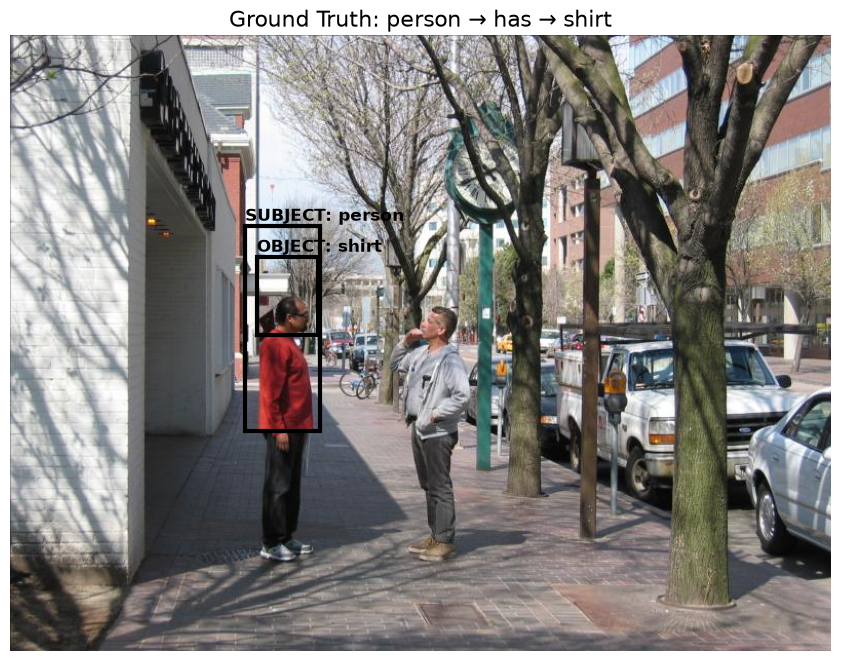

In [59]:
# CELL 11: VISUALIZE SELECTED SUBJECT + OBJECT

fig, ax = plt.subplots(
    figsize=(12, 8)
)

ax.imshow(scene.image)

# ------------------------------------------------------------
# Helper to convert center-format bbox to corners
# ------------------------------------------------------------

def bbox_to_xyxy(bbox):

    x1 = bbox.cx - bbox.width / 2
    y1 = bbox.cy - bbox.height / 2

    x2 = bbox.cx + bbox.width / 2
    y2 = bbox.cy + bbox.height / 2

    return x1, y1, x2, y2


# ------------------------------------------------------------
# Subject box
# ------------------------------------------------------------

sx1, sy1, sx2, sy2 = bbox_to_xyxy(
    subject.bbox
)

subject_rect = plt.Rectangle(
    (sx1, sy1),
    sx2 - sx1,
    sy2 - sy1,
    fill=False,
    linewidth=3,
)

ax.add_patch(subject_rect)

ax.text(
    sx1,
    sy1 - 5,
    f"SUBJECT: {subject.label}",
    fontsize=12,
    weight="bold",
)


# ------------------------------------------------------------
# Object box
# ------------------------------------------------------------

ox1, oy1, ox2, oy2 = bbox_to_xyxy(
    obj.bbox
)

object_rect = plt.Rectangle(
    (ox1, oy1),
    ox2 - ox1,
    oy2 - oy1,
    fill=False,
    linewidth=3,
)

ax.add_patch(object_rect)

ax.text(
    ox1,
    oy1 - 5,
    f"OBJECT: {obj.label}",
    fontsize=12,
    weight="bold",
)


ax.set_title(
    f"Ground Truth: "
    f"{subject.label} → "
    f"{selected_relationship.predicate} → "
    f"{obj.label}",
    fontsize=16,
)

ax.axis("off")

plt.show()

In [60]:
# CELL 12: BUILD TRAINING-CONSISTENT UNION BOX

from models.relationship.geometry import (
    get_union_bbox,
    crop_union_region,
    bbox_relative_to_crop,
    normalize_bbox,
)

# IMPORTANT:
# Training used expansion = 0.20

union_box = get_union_bbox(
    subject.bbox,
    obj.bbox,
    expansion=0.20,
)

print("TRAINING-CONSISTENT UNION")
print("-" * 60)

print("Subject :", subject.label)
print("Object  :", obj.label)

print()
print("Union bbox:")
print(union_box)

TRAINING-CONSISTENT UNION
------------------------------------------------------------
Subject : person
Object  : shirt

Union bbox:
BoundingBox(cx=264.84375, cy=285.3515625, width=87.1875, height=239.765625)


Union crop size: (87, 240)


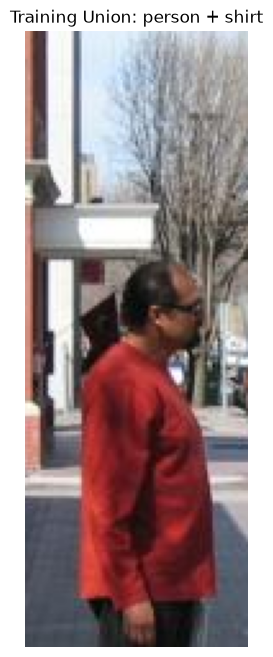

In [61]:
# CELL 13: CREATE TRAINING-CONSISTENT UNION CROP

union_crop = crop_union_region(
    scene.image,
    union_box,
)

print("Union crop size:", union_crop.size)

plt.figure(figsize=(8, 8))
plt.imshow(union_crop)

plt.title(
    f"Training Union: "
    f"{subject.label} + {obj.label}"
)

plt.axis("off")
plt.show()

In [62]:
# CELL 14: BUILD 8-D GEOMETRY

subject_relative = bbox_relative_to_crop(
    subject.bbox,
    union_box,
)

object_relative = bbox_relative_to_crop(
    obj.bbox,
    union_box,
)

subject_normalized = normalize_bbox(
    subject_relative,
    union_box,
)

object_normalized = normalize_bbox(
    object_relative,
    union_box,
)


geometry = torch.tensor(
    [
        subject_normalized.cx,
        subject_normalized.cy,
        subject_normalized.width,
        subject_normalized.height,

        object_normalized.cx,
        object_normalized.cy,
        object_normalized.width,
        object_normalized.height,
    ],
    dtype=torch.float32,
)


print("8-D GEOMETRY")
print("-" * 60)

print("Subject normalized:")
print(
    subject_normalized
)

print()
print("Object normalized:")
print(
    object_normalized
)

print()
print("Geometry:")
print(geometry)

print()
print("Shape:", tuple(geometry.shape))

8-D GEOMETRY
------------------------------------------------------------
Subject normalized:
BoundingBox(cx=0.5, cy=0.5, width=0.8333333333333334, height=0.8333333333333334)

Object normalized:
BoundingBox(cx=0.553763440860215, cy=0.36803519061583573, width=0.6810035842293907, height=0.3176930596285436)

Geometry:
tensor([0.5000, 0.5000, 0.8333, 0.8333, 0.5538, 0.3680, 0.6810, 0.3177])

Shape: (8,)


In [63]:
# CELL 15: LOAD VISUAL ENCODER

from models.relationship.encoder import ImageEncoder

visual_encoder = ImageEncoder(
    model_name="ViT-B-32",
    pretrained="openai",
    device=device,
)

print("Visual encoder loaded")
print("Model      : ViT-B-32")
print("Pretrained : openai")

c:\Users\psytr\Desktop\Projects\scene_graph\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Visual encoder loaded
Model      : ViT-B-32
Pretrained : openai


In [64]:
# CELL 16: EXTRACT 512-D UNION FEATURE

visual_input = visual_encoder.preprocess(
    union_crop
).unsqueeze(0).to(device)

print("Preprocessed image:")
print("Shape:", tuple(visual_input.shape))

with torch.no_grad():

    visual_feature = visual_encoder(
        visual_input
    )

print()
print("Visual feature:")
print("Shape:", tuple(visual_feature.shape))
print("Dtype:", visual_feature.dtype)

Preprocessed image:
Shape: (1, 3, 224, 224)

Visual feature:
Shape: (1, 512)
Dtype: torch.float32


In [65]:
# CELL 17: PREDICT RELATIONSHIP

model.eval()

# Visual feature
visual_input = visual_feature.to(device)

# Convert Visual Genome's 1-based label IDs
# to the 0-based indices expected by nn.Embedding.
subject_label_input = torch.tensor(
    [subject.label_index - 1],
    dtype=torch.long,
    device=device
)

object_label_input = torch.tensor(
    [obj.label_index - 1],
    dtype=torch.long,
    device=device
)

# Geometry
geometry_input = geometry.unsqueeze(0).to(device)

with torch.no_grad():

    logits = model(
        visual=visual_input,
        subject_label=subject_label_input,
        object_label=object_label_input,
        geometry=geometry_input,
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[
        0,
        predicted_class
    ].item()


print("RELATIONSHIP PREDICTION")
print("-" * 60)

print("Subject      :", subject.label)
print("Object       :", obj.label)

print(
    "Ground truth :",
    selected_relationship.predicate,
    f"(class {selected_relationship.predicate_index})"
)

print(
    "Prediction   :",
    predicted_class
)

print(
    "Confidence   :",
    f"{confidence * 100:.2f}%"
)

RELATIONSHIP PREDICTION
------------------------------------------------------------
Subject      : person
Object       : shirt
Ground truth : has (class 20)
Prediction   : 47
Confidence   : 69.59%


In [66]:
# CELL 18: CORRECTLY DECODE PREDICTION

# ============================================================
# MODEL PREDICATE MAPPING
# ============================================================
# Visual Genome predicates use IDs 1..50.
# Training converted them to model classes 0..49 using -1.
# Model class 50 is reserved for "no relationship".

idx_to_predicate = {
    int(idx) - 1: name
    for name, idx in loader.dictionary["predicate_to_idx"].items()
}

idx_to_predicate[50] = "no relationship"

predicted_predicate = idx_to_predicate[predicted_class]

ground_truth_class = (
    selected_relationship.predicate_index - 1
)

ground_truth_predicate = selected_relationship.predicate

ground_truth_class = (
    selected_relationship.predicate_index - 1
)

ground_truth_predicate = (
    selected_relationship.predicate
)

print()
print("RELATIONSHIP RESULT")
print("-" * 60)

print("Subject      :", subject.label)
print("Object       :", obj.label)

print(
    "Ground truth :",
    ground_truth_predicate,
    f"(model class {ground_truth_class})"
)

print(
    "Prediction   :",
    predicted_predicate,
    f"(model class {predicted_class})"
)

print(
    "Confidence   :",
    f"{confidence * 100:.2f}%"
)

print()

if predicted_class == ground_truth_class:
    print("✅ EXACT MATCH")
else:
    print("❌ DIFFERENT FROM ANNOTATION")


RELATIONSHIP RESULT
------------------------------------------------------------
Subject      : person
Object       : shirt
Ground truth : has (model class 19)
Prediction   : wearing (model class 47)
Confidence   : 69.59%

❌ DIFFERENT FROM ANNOTATION


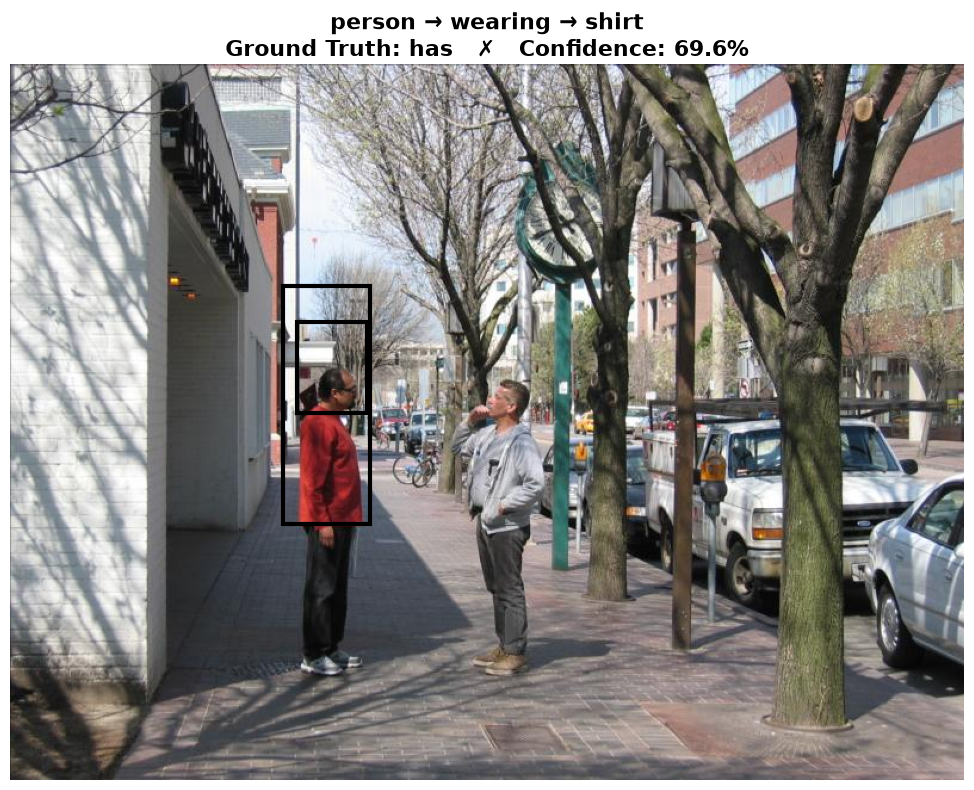

In [67]:
# CELL 19: FINAL VISUAL RESULT

fig, ax = plt.subplots(
    figsize=(12, 8)
)

ax.imshow(scene.image)

# Subject box
ax.add_patch(
    plt.Rectangle(
        (sx1, sy1),
        sx2 - sx1,
        sy2 - sy1,
        fill=False,
        linewidth=3,
    )
)

# Object box
ax.add_patch(
    plt.Rectangle(
        (ox1, oy1),
        ox2 - ox1,
        oy2 - oy1,
        fill=False,
        linewidth=3,
    )
)

is_correct = (
    predicted_class == ground_truth_class
)

symbol = "✓" if is_correct else "✗"

title = (
    f"{subject.label} → "
    f"{predicted_predicate} → "
    f"{obj.label}\n"
    f"Ground Truth: {ground_truth_predicate}   "
    f"{symbol}   "
    f"Confidence: {confidence * 100:.1f}%"
)

ax.set_title(
    title,
    fontsize=16,
    weight="bold",
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [68]:
# CELL 20: SELECT A SPATIAL RELATIONSHIP

spatial_predicates = {
    "above",
    "below",
    "behind",
    "in front of",
    "near",
    "on",
    "in",
    "under",
    "over",
    "outside",
    "parked on",
    "sitting on",
    "standing on",
}

spatial_relationship = None

for rel in scene.relationships:

    if rel.predicate in spatial_predicates:

        if (
            rel.subject.object_index
            != rel.object.object_index
        ):
            spatial_relationship = rel
            break


if spatial_relationship is None:
    raise RuntimeError(
        "No spatial relationship found."
    )


subject = spatial_relationship.subject
obj = spatial_relationship.object

ground_truth_class = (
    spatial_relationship.predicate_index - 1
)

print("SPATIAL RELATIONSHIP TEST")
print("-" * 60)

print(
    "Subject      :",
    subject.label,
    f"(object {subject.object_index})"
)

print(
    "Object       :",
    obj.label,
    f"(object {obj.object_index})"
)

print(
    "Ground truth :",
    spatial_relationship.predicate,
)

print(
    "Ground truth class :",
    ground_truth_class
)

SPATIAL RELATIONSHIP TEST
------------------------------------------------------------
Subject      : sign (object 5)
Object       : building (object 6)
Ground truth : on
Ground truth class : 29


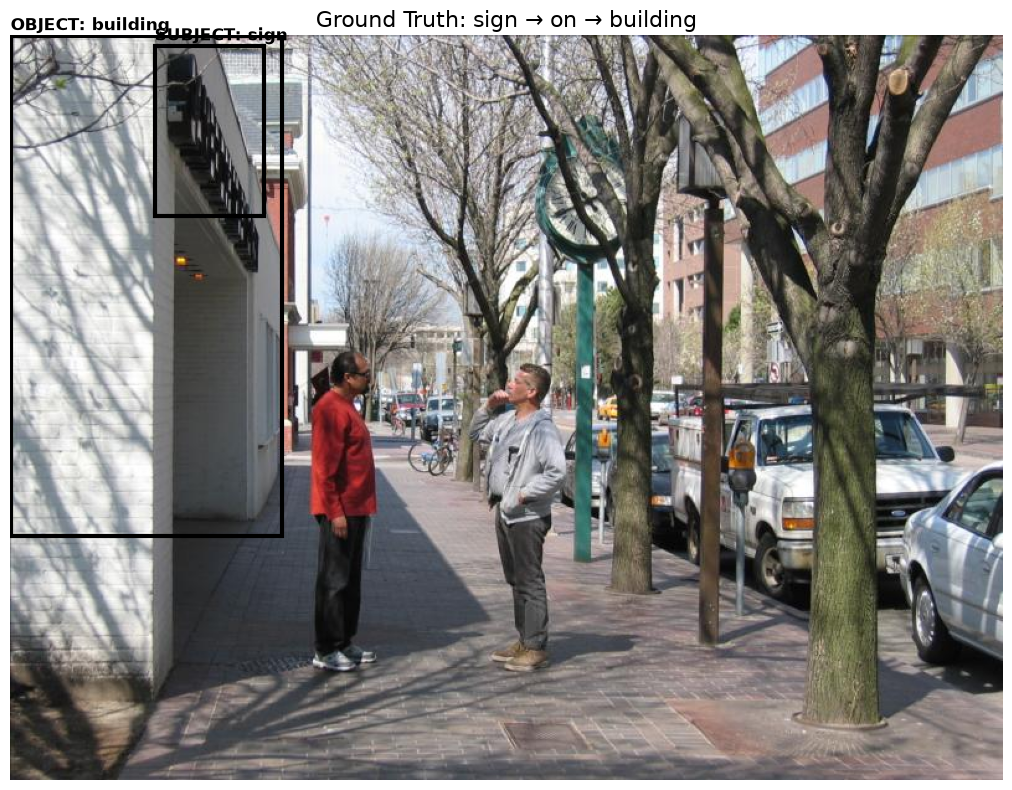

In [69]:
# CELL 21: VISUALIZE SPATIAL PAIR

sx1, sy1, sx2, sy2 = bbox_to_xyxy(
    subject.bbox
)

ox1, oy1, ox2, oy2 = bbox_to_xyxy(
    obj.bbox
)

fig, ax = plt.subplots(
    figsize=(12, 8)
)

ax.imshow(scene.image)

ax.add_patch(
    plt.Rectangle(
        (sx1, sy1),
        sx2 - sx1,
        sy2 - sy1,
        fill=False,
        linewidth=3,
    )
)

ax.add_patch(
    plt.Rectangle(
        (ox1, oy1),
        ox2 - ox1,
        oy2 - oy1,
        fill=False,
        linewidth=3,
    )
)

ax.text(
    sx1,
    sy1 - 5,
    f"SUBJECT: {subject.label}",
    fontsize=12,
    weight="bold",
)

ax.text(
    ox1,
    oy1 - 5,
    f"OBJECT: {obj.label}",
    fontsize=12,
    weight="bold",
)

ax.set_title(
    f"Ground Truth: "
    f"{subject.label} → "
    f"{spatial_relationship.predicate} → "
    f"{obj.label}",
    fontsize=16,
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [70]:
# CELL 22: BUILD UNION AND GEOMETRY

union_box = get_union_bbox(
    subject.bbox,
    obj.bbox,
    expansion=0.20,
)

union_crop = crop_union_region(
    scene.image,
    union_box,
)

subject_relative = bbox_relative_to_crop(
    subject.bbox,
    union_box,
)

object_relative = bbox_relative_to_crop(
    obj.bbox,
    union_box,
)

subject_normalized = normalize_bbox(
    subject_relative,
    union_box,
)

object_normalized = normalize_bbox(
    object_relative,
    union_box,
)

geometry = torch.tensor(
    [
        subject_normalized.cx,
        subject_normalized.cy,
        subject_normalized.width,
        subject_normalized.height,

        object_normalized.cx,
        object_normalized.cy,
        object_normalized.width,
        object_normalized.height,
    ],
    dtype=torch.float32,
)

print("Union crop:", union_crop.size)
print("Geometry :", geometry)
print("Geometry shape:", tuple(geometry.shape))

Union crop: (241, 443)
Geometry : tensor([0.6935, 0.2416, 0.3363, 0.2826, 0.5000, 0.5000, 0.8333, 0.8333])
Geometry shape: (8,)


In [71]:
# CELL 23: EXTRACT 512-D VISUAL FEATURE

visual_input = (
    visual_encoder.preprocess(
        union_crop
    )
    .unsqueeze(0)
    .to(device)
)

with torch.no_grad():

    visual_feature = visual_encoder(
        visual_input
    )

print("Visual feature shape:",
      tuple(visual_feature.shape))

Visual feature shape: (1, 512)


In [72]:
# CELL 24: PREDICT SPATIAL RELATIONSHIP

subject_label_input = torch.tensor(
    [subject.label_index - 1],
    dtype=torch.long,
    device=device
)

object_label_input = torch.tensor(
    [obj.label_index - 1],
    dtype=torch.long,
    device=device
)

geometry_input = (
    geometry
    .unsqueeze(0)
    .to(device)
)

with torch.no_grad():

    logits = model(
        visual=visual_feature,
        subject_label=subject_label_input,
        object_label=object_label_input,
        geometry=geometry_input,
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[
        0,
        predicted_class
    ].item()


predicted_predicate = idx_to_predicate[
    predicted_class
]

print()
print("=" * 60)
print("SPATIAL RELATIONSHIP RESULT")
print("=" * 60)

print()

print(
    f"Subject      : {subject.label}"
)

print(
    f"Object       : {obj.label}"
)

print(
    f"Ground truth : "
    f"{spatial_relationship.predicate}"
)

print(
    f"Prediction   : "
    f"{predicted_predicate}"
)

print(
    f"Confidence   : "
    f"{confidence * 100:.2f}%"
)

print()

if predicted_class == ground_truth_class:
    print("✅ EXACT MATCH")
else:
    print("❌ DIFFERENT FROM ANNOTATION")


SPATIAL RELATIONSHIP RESULT

Subject      : sign
Object       : building
Ground truth : on
Prediction   : on
Confidence   : 58.64%

✅ EXACT MATCH


## Stage 2 
Use YOLO to predict objects and then predict relationships from them

In [73]:
# CELL 25: LOAD YOLO-WORLD

from ultralytics import YOLOWorld

YOLO_MODEL_PATH = os.path.join(
    NOTEBOOK_DIR,
    "models",
    "yolov8s-world.pt"
)

print("YOLO model path:")
print(YOLO_MODEL_PATH)

print()
print("Exists:", os.path.exists(YOLO_MODEL_PATH))

yolo_model = YOLOWorld(
    YOLO_MODEL_PATH
)

print()
print("YOLO-World loaded successfully")

YOLO model path:
C:\Users\psytr\Desktop\Projects\scene_graph\notebook\models\yolov8s-world.pt

Exists: True

YOLO-World loaded successfully


In [74]:
# CELL 26: CONFIGURE YOLO WITH VISUAL GENOME CLASSES

vg_classes = list(
    loader.dictionary["label_to_idx"].keys()
)

if "background" in vg_classes:
    vg_classes.remove("background")

yolo_model.set_classes(
    vg_classes
)

print("YOLO classes configured")
print()
print("Number of classes:", len(vg_classes))
print()
print("First 20 classes:")
print(vg_classes[:20])

YOLO classes configured

Number of classes: 149

First 20 classes:
['air', 'airplane', 'animal', 'arm', 'back', 'bag', 'banana', 'basket', 'beach', 'bear', 'bed', 'bench', 'bike', 'bird', 'board', 'boat', 'book', 'bottle', 'bowl', 'box']


In [75]:
# CELL 27: TEST IMAGE

TEST_IMAGE_PATH = os.path.join(
    VG_ROOT,
    "VG_100K_2",
    "1.jpg"
)

print("Test image:")
print(TEST_IMAGE_PATH)

print()
print("Exists:",
      os.path.exists(TEST_IMAGE_PATH))

Test image:
C:\Users\psytr\Desktop\Projects\scene_graph\datasets\visual_genome\VG_100K_2\1.jpg

Exists: True


In [76]:
# CELL 28: YOLO OBJECT DETECTION

yolo_results = yolo_model.predict(
    TEST_IMAGE_PATH,
    conf=0.25,
    verbose=False
)

yolo_result = yolo_results[0]

print("YOLO detection complete")
print()
print("Number of detections:",
      len(yolo_result.boxes))

YOLO detection complete

Number of detections: 9


In [77]:
# CELL 29: EXTRACT DETECTED OBJECTS

detected_objects = []

boxes = yolo_result.boxes

for i in range(len(boxes)):

    cls_id = int(
        boxes.cls[i].item()
    )

    confidence = float(
        boxes.conf[i].item()
    )

    xyxy = (
        boxes.xyxy[i]
        .cpu()
        .numpy()
        .tolist()
    )

    label = yolo_result.names[
        cls_id
    ]

    detected_objects.append(
        {
            "detection_index": i,
            "class_id": cls_id,
            "label": label,
            "confidence": confidence,
            "xyxy": xyxy,
        }
    )


print("DETECTED OBJECTS")
print("-" * 60)

for obj_det in detected_objects:

    print(
        f"[{obj_det['detection_index']}] "
        f"{obj_det['label']:<20} "
        f"conf={obj_det['confidence']:.3f} "
        f"box={obj_det['xyxy']}"
    )

print()
print(
    "Total detections:",
    len(detected_objects)
)

DETECTED OBJECTS
------------------------------------------------------------
[0] person               conf=0.813 box=[375.47674560546875, 263.0340576171875, 449.1826477050781, 512.1076049804688]
[1] person               conf=0.770 box=[239.50686645507812, 253.28997802734375, 298.1173400878906, 514.2042236328125]
[2] car                  conf=0.646 box=[717.71728515625, 339.4010009765625, 800.0, 531.846923828125]
[3] bike                 conf=0.564 box=[323.439697265625, 316.5541076660156, 362.338623046875, 355.2013244628906]
[4] vehicle              conf=0.436 box=[530.6077880859375, 290.4277038574219, 772.4210815429688, 458.95513916015625]
[5] shoe                 conf=0.372 box=[396.45306396484375, 492.1694030761719, 434.4500427246094, 512.47265625]
[6] sidewalk             conf=0.300 box=[45.08811950683594, 328.1303405761719, 799.0093994140625, 599.9295043945312]
[7] tree                 conf=0.266 box=[191.0992431640625, 0.03582000732421875, 797.2879028320312, 562.7760009765625]
[

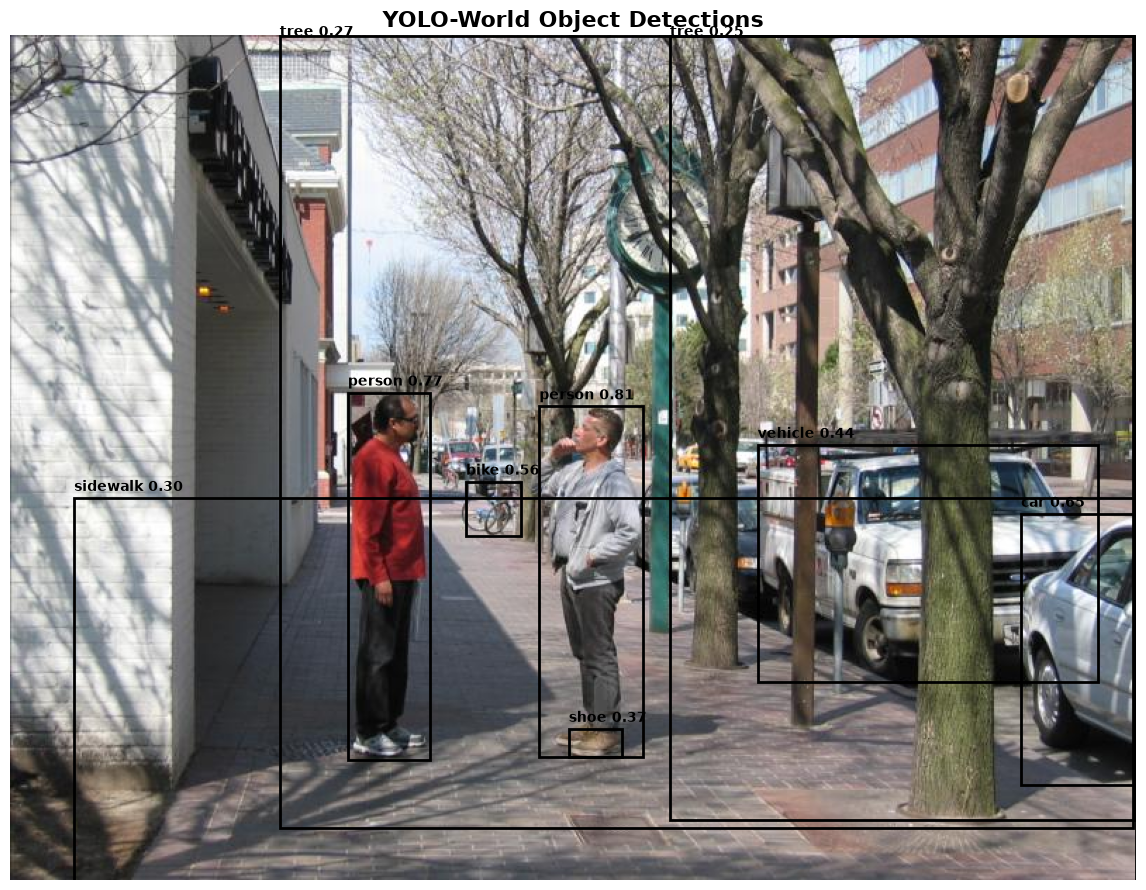

In [78]:
# CELL 30: VISUALIZE YOLO DETECTIONS

image = Image.open(
    TEST_IMAGE_PATH
).convert("RGB")

fig, ax = plt.subplots(
    figsize=(14, 9)
)

ax.imshow(image)

for det in detected_objects:

    x1, y1, x2, y2 = det["xyxy"]

    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2,
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        max(0, y1 - 5),
        f"{det['label']} "
        f"{det['confidence']:.2f}",
        fontsize=10,
        weight="bold",
    )

ax.set_title(
    "YOLO-World Object Detections",
    fontsize=16,
    weight="bold",
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [79]:
# CELL 31: BUILD VG LABEL MAPPING

vg_label_to_idx = {
    name: int(idx)
    for name, idx
    in loader.dictionary["label_to_idx"].items()
}

print("Example mappings:")

for name in [
    "person",
    "shirt",
    "bike",
    "car",
]:

    if name in vg_label_to_idx:

        print(
            f"{name:<15} "
            f"VG ID = {vg_label_to_idx[name]}"
        )

Example mappings:
person          VG ID = 95
shirt           VG ID = 114
bike            VG ID = 14
car             VG ID = 30


In [80]:
# CELL 32: FILTER RELATIONSHIP-COMPATIBLE OBJECTS

relationship_objects = []

for det in detected_objects:

    label = det["label"]

    if label not in vg_label_to_idx:
        continue

    vg_label_id = vg_label_to_idx[
        label
    ]

    relationship_objects.append(
        {
            **det,
            "vg_label_id": vg_label_id,
            "model_label_id": vg_label_id - 1,
        }
    )


print("RELATIONSHIP-COMPATIBLE OBJECTS")
print("-" * 60)

for obj_det in relationship_objects:

    print(
        f"[{obj_det['detection_index']}] "
        f"{obj_det['label']:<20} "
        f"conf={obj_det['confidence']:.3f} "
        f"model_id={obj_det['model_label_id']}"
    )

print()
print(
    "Usable objects:",
    len(relationship_objects)
)

RELATIONSHIP-COMPATIBLE OBJECTS
------------------------------------------------------------
[0] person               conf=0.813 model_id=94
[1] person               conf=0.770 model_id=94
[2] car                  conf=0.646 model_id=29
[3] bike                 conf=0.564 model_id=13
[4] vehicle              conf=0.436 model_id=141
[5] shoe                 conf=0.372 model_id=114
[6] sidewalk             conf=0.300 model_id=116
[7] tree                 conf=0.266 model_id=137
[8] tree                 conf=0.255 model_id=137

Usable objects: 9


In [81]:
# CELL 33: GENERATE ORDERED OBJECT PAIRS

pairs = []

for i, subject_det in enumerate(
    relationship_objects
):

    for j, object_det in enumerate(
        relationship_objects
    ):

        if i == j:
            continue

        pairs.append(
            (
                subject_det,
                object_det
            )
        )


print(
    "Number of ordered pairs:",
    len(pairs)
)

Number of ordered pairs: 72


In [102]:
# CELL 34: SELECT CONFIDENT DETECTIONS

CONF_THRESHOLD = 0

test_objects = [
    obj
    for obj in relationship_objects
    if obj["confidence"] >= CONF_THRESHOLD
]

print("CONFIDENT OBJECTS")
print("-" * 60)

for obj in test_objects:
    print(
        f"[{obj['detection_index']}] "
        f"{obj['label']:<15} "
        f"confidence={obj['confidence']:.3f}"
    )

print()
print("Total objects:", len(test_objects))
print(
    "Ordered pairs:",
    len(test_objects) * (len(test_objects) - 1)
)

CONFIDENT OBJECTS
------------------------------------------------------------
[0] person          confidence=0.813
[1] person          confidence=0.770
[2] car             confidence=0.646
[3] bike            confidence=0.564
[4] vehicle         confidence=0.436
[5] shoe            confidence=0.372
[6] sidewalk        confidence=0.300
[7] tree            confidence=0.266
[8] tree            confidence=0.255

Total objects: 9
Ordered pairs: 72


In [103]:
# CELL 35: CONVERT YOLO BOX TO BOUNDING BOX

from datasets.visual_genome import BoundingBox


def yolo_box_to_bbox(xyxy):

    x1, y1, x2, y2 = xyxy

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    width = x2 - x1
    height = y2 - y1

    return BoundingBox(
        cx=cx,
        cy=cy,
        width=width,
        height=height,
    )


print("BoundingBox conversion helper ready")

BoundingBox conversion helper ready


In [104]:
# CELL 36: PREPARE ONE DETECTED OBJECT PAIR

pair_subject = test_objects[0]
pair_object = test_objects[1]

subject_bbox = yolo_box_to_bbox(
    pair_subject["xyxy"]
)

object_bbox = yolo_box_to_bbox(
    pair_object["xyxy"]
)

print("SUBJECT")
print("-" * 60)
print(pair_subject["label"])
print(subject_bbox)

print()
print("OBJECT")
print("-" * 60)
print(pair_object["label"])
print(object_bbox)

SUBJECT
------------------------------------------------------------
person
BoundingBox(cx=412.32969665527344, cy=387.5708312988281, width=73.70590209960938, height=249.07354736328125)

OBJECT
------------------------------------------------------------
person
BoundingBox(cx=268.8121032714844, cy=383.7471008300781, width=58.6104736328125, height=260.91424560546875)


In [105]:
# CELL 37: BUILD UNION CROP + GEOMETRY

union_box = get_union_bbox(
    subject_bbox,
    object_bbox,
    expansion=0.20,
)

union_crop = crop_union_region(
    image,
    union_box,
)

# Relative boxes
subject_relative = bbox_relative_to_crop(
    subject_bbox,
    union_box,
)

object_relative = bbox_relative_to_crop(
    object_bbox,
    union_box,
)

# Normalize
subject_normalized = normalize_bbox(
    subject_relative,
    union_box,
)

object_normalized = normalize_bbox(
    object_relative,
    union_box,
)

geometry_input = torch.tensor(
    [
        subject_normalized.cx,
        subject_normalized.cy,
        subject_normalized.width,
        subject_normalized.height,

        object_normalized.cx,
        object_normalized.cy,
        object_normalized.width,
        object_normalized.height,
    ],
    dtype=torch.float32,
)

print("Union crop :", union_crop.size)
print("Geometry   :", geometry_input)
print("Shape      :", tuple(geometry_input.shape))

Union crop : (223, 313)
Geometry   : tensor([0.8016, 0.5122, 0.3307, 0.7955, 0.1578, 0.5000, 0.2629, 0.8333])
Shape      : (8,)


In [106]:
# CELL 38: EXTRACT VISUAL FEATURE

visual_input = (
    visual_encoder.preprocess(
        union_crop
    )
    .unsqueeze(0)
    .to(device)
)

with torch.no_grad():

    pair_visual_feature = visual_encoder(
        visual_input
    )

print(
    "Visual feature shape:",
    tuple(pair_visual_feature.shape)
)

Visual feature shape: (1, 512)


In [107]:
# ============================================================
# CELL 39A: CORRECT MODEL PREDICATE MAPPING
# ============================================================

# Visual Genome predicate IDs:
#   1..50 = real predicates
#
# Training cache conversion:
#   model_class = predicate_index - 1
#
# Therefore:
#   VG 1  -> model 0
#   VG 2  -> model 1
#   ...
#   VG 50 -> model 49
#   model 50 -> no relationship

predicate_to_idx = loader.dictionary["predicate_to_idx"]

idx_to_predicate = {
    int(idx) - 1: predicate
    for predicate, idx in predicate_to_idx.items()
}

# Special class added during training
idx_to_predicate[50] = "no relationship"

print("MODEL PREDICATE MAPPING")
print("-" * 60)

for idx in range(51):
    print(
        f"{idx:2d} → {idx_to_predicate[idx]}"
    )

print()
print("Total model classes:", len(idx_to_predicate))

MODEL PREDICATE MAPPING
------------------------------------------------------------
 0 → above
 1 → across
 2 → against
 3 → along
 4 → and
 5 → at
 6 → attached to
 7 → behind
 8 → between
 9 → carrying
10 → covered in
11 → covering
12 → crossing
13 → eating
14 → flying
15 → flying in
16 → for
17 → from
18 → hanging from
19 → has
20 → holding
21 → in
22 → in front of
23 → laying on
24 → looking at
25 → lying on
26 → mounted on
27 → near
28 → of
29 → on
30 → outside
31 → over
32 → painted on
33 → parked on
34 → playing
35 → riding
36 → says
37 → sitting at
38 → sitting on
39 → standing on
40 → to
41 → under
42 → underneath
43 → using
44 → walking in
45 → walking on
46 → watching
47 → wearing
48 → with
49 → worn by
50 → no relationship

Total model classes: 51


In [108]:
# CELL 39: TEST ONE DETECTED PAIR

subject_model_id = pair_subject[
    "model_label_id"
]

object_model_id = pair_object[
    "model_label_id"
]

subject_tensor = torch.tensor(
    [subject_model_id],
    dtype=torch.long,
    device=device,
)

object_tensor = torch.tensor(
    [object_model_id],
    dtype=torch.long,
    device=device,
)

geometry_tensor = (
    geometry_input
    .unsqueeze(0)
    .to(device)
)

model.eval()

with torch.no_grad():

    logits = model(
        visual=pair_visual_feature,
        subject_label=subject_tensor,
        object_label=object_tensor,
        geometry=geometry_tensor,
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[
        0,
        predicted_class
    ].item()


predicted_predicate = idx_to_predicate[
    predicted_class
]

print("SINGLE DETECTED PAIR")
print("-" * 60)

print(
    f"{pair_subject['label']} "
    f"→ {predicted_predicate} "
    f"→ {pair_object['label']}"
)

print(
    "Prediction class:",
    predicted_class
)

print(
    "Relationship confidence:",
    f"{confidence * 100:.2f}%"
)

SINGLE DETECTED PAIR
------------------------------------------------------------
person → no relationship → person
Prediction class: 50
Relationship confidence: 58.27%


In [109]:
# CELL 40: GENERATE VALID OBJECT PAIRS

pairs = []

for i, subject_det in enumerate(test_objects):

    for j, object_det in enumerate(test_objects):

        if i == j:
            continue

        # Avoid same-category pairs for this first test
        if subject_det["label"] == object_det["label"]:
            continue

        pairs.append(
            (
                subject_det,
                object_det
            )
        )


print("VALID ORDERED PAIRS")
print("-" * 60)

for subject_det, object_det in pairs:

    print(
        f"{subject_det['label']:<15}"
        f" → "
        f"{object_det['label']}"
    )

print()
print("Total valid pairs:", len(pairs))

VALID ORDERED PAIRS
------------------------------------------------------------
person          → car
person          → bike
person          → vehicle
person          → shoe
person          → sidewalk
person          → tree
person          → tree
person          → car
person          → bike
person          → vehicle
person          → shoe
person          → sidewalk
person          → tree
person          → tree
car             → person
car             → person
car             → bike
car             → vehicle
car             → shoe
car             → sidewalk
car             → tree
car             → tree
bike            → person
bike            → person
bike            → car
bike            → vehicle
bike            → shoe
bike            → sidewalk
bike            → tree
bike            → tree
vehicle         → person
vehicle         → person
vehicle         → car
vehicle         → bike
vehicle         → shoe
vehicle         → sidewalk
vehicle         → tree
vehicle         → tree
shoe 

In [110]:
# CELL 41: PREDICT ALL VALID RELATIONSHIPS

predicted_relationships = []

model.eval()

for subject_det, object_det in pairs:

    # --------------------------------------------------------
    # Convert YOLO boxes to BoundingBox
    # --------------------------------------------------------

    subject_bbox = yolo_box_to_bbox(
        subject_det["xyxy"]
    )

    object_bbox = yolo_box_to_bbox(
        object_det["xyxy"]
    )

    # --------------------------------------------------------
    # Union crop
    # --------------------------------------------------------

    union_box = get_union_bbox(
        subject_bbox,
        object_bbox,
        expansion=0.20,
    )

    union_crop = crop_union_region(
        image,
        union_box,
    )

    # --------------------------------------------------------
    # Geometry
    # --------------------------------------------------------

    subject_relative = bbox_relative_to_crop(
        subject_bbox,
        union_box
    )

    object_relative = bbox_relative_to_crop(
        object_bbox,
        union_box
    )

    subject_normalized = normalize_bbox(
        subject_relative,
        union_box
    )

    object_normalized = normalize_bbox(
        object_relative,
        union_box
    )

    geometry = torch.tensor(
        [
            subject_normalized.cx,
            subject_normalized.cy,
            subject_normalized.width,
            subject_normalized.height,

            object_normalized.cx,
            object_normalized.cy,
            object_normalized.width,
            object_normalized.height,
        ],
        dtype=torch.float32,
    )

    # --------------------------------------------------------
    # 512-D visual feature
    # --------------------------------------------------------

    visual_input = (
        visual_encoder
        .preprocess(union_crop)
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        visual_feature = visual_encoder(
            visual_input
        )

        # ----------------------------------------------------
        # Object labels
        # ----------------------------------------------------

        subject_tensor = torch.tensor(
            [subject_det["model_label_id"]],
            dtype=torch.long,
            device=device,
        )

        object_tensor = torch.tensor(
            [object_det["model_label_id"]],
            dtype=torch.long,
            device=device,
        )

        geometry_tensor = (
            geometry
            .unsqueeze(0)
            .to(device)
        )

        # ----------------------------------------------------
        # Relationship prediction
        # ----------------------------------------------------

        logits = model(
            visual=visual_feature,
            subject_label=subject_tensor,
            object_label=object_tensor,
            geometry=geometry_tensor,
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predicted_class = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_class
        ].item()

    predicted_predicate = idx_to_predicate[
        predicted_class
    ]

    predicted_relationships.append(
        {
            "subject": subject_det["label"],
            "object": object_det["label"],
            "predicate": predicted_predicate,
            "class": predicted_class,
            "confidence": confidence,
            "subject_confidence":
                subject_det["confidence"],
            "object_confidence":
                object_det["confidence"],
        }
    )


print("RAW RELATIONSHIP PREDICTIONS")
print("-" * 60)

for rel in predicted_relationships:

    print(
        f"{rel['subject']:<12} "
        f"→ {rel['predicate']:<20} "
        f"→ {rel['object']:<12} "
        f"({rel['confidence'] * 100:.2f}%)"
    )

RAW RELATIONSHIP PREDICTIONS
------------------------------------------------------------
person       → no relationship      → car          (73.88%)
person       → riding               → bike         (21.79%)
person       → no relationship      → vehicle      (63.48%)
person       → wearing              → shoe         (77.61%)
person       → walking on           → sidewalk     (66.48%)
person       → no relationship      → tree         (41.16%)
person       → no relationship      → tree         (63.29%)
person       → no relationship      → car          (85.26%)
person       → no relationship      → bike         (35.29%)
person       → no relationship      → vehicle      (83.78%)
person       → no relationship      → shoe         (63.96%)
person       → walking on           → sidewalk     (68.69%)
person       → no relationship      → tree         (46.26%)
person       → no relationship      → tree         (79.44%)
car          → no relationship      → person       (79.43%)
car       

In [111]:
# CELL 42: RELATIONSHIP SUMMARY

print("RELATIONSHIP SUMMARY")
print("-" * 60)

related = []
unrelated = []

for rel in predicted_relationships:

    if rel["class"] == 50:
        unrelated.append(rel)
    else:
        related.append(rel)


print(
    "Pairs with relationship :",
    len(related)
)

print(
    "Pairs with no relationship:",
    len(unrelated)
)

print()

print("PREDICTED RELATIONSHIPS")
print("-" * 60)

for rel in related:

    print(
        f"{rel['subject']} "
        f"→ {rel['predicate']} "
        f"→ {rel['object']} "
        f"({rel['confidence'] * 100:.2f}%)"
    )

print()

print("NO RELATIONSHIP")
print("-" * 60)

for rel in unrelated:

    print(
        f"{rel['subject']} "
        f"→ no relationship → "
        f"{rel['object']} "
        f"({rel['confidence'] * 100:.2f}%)"
    )

RELATIONSHIP SUMMARY
------------------------------------------------------------
Pairs with relationship : 17
Pairs with no relationship: 51

PREDICTED RELATIONSHIPS
------------------------------------------------------------
person → riding → bike (21.79%)
person → wearing → shoe (77.61%)
person → walking on → sidewalk (66.48%)
person → walking on → sidewalk (68.69%)
car → on → sidewalk (32.46%)
bike → on → sidewalk (54.03%)
vehicle → on → sidewalk (57.99%)
vehicle → behind → tree (30.81%)
shoe → on → person (41.60%)
shoe → on → sidewalk (49.01%)
tree → behind → person (65.83%)
tree → behind → person (64.82%)
tree → behind → car (40.75%)
tree → on → sidewalk (53.51%)
tree → behind → person (51.32%)
tree → behind → person (56.62%)
tree → on → sidewalk (47.35%)

NO RELATIONSHIP
------------------------------------------------------------
person → no relationship → car (73.88%)
person → no relationship → vehicle (63.48%)
person → no relationship → tree (41.16%)
person → no relationship